# House pricing

Este notebook corresponde a una práctica de regresión de Kaggle vinculada a los precios de propiedades en función de sus características.

In [942]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, FunctionTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

## Análisis y preprocesamiento

In [943]:
data = pd.read_csv("./train.csv")
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [944]:
data.shape

(1460, 81)

In [945]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [946]:
data.isna().sum().values

array([   0,    0,    0,  259,    0,    0, 1369,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,  872,    8,    0,    0,    0,   37,   37,   38,
         37,    0,   38,    0,    0,    0,    0,    0,    0,    1,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,  690,   81,   81,   81,    0,    0,   81,   81,    0,
          0,    0,    0,    0,    0,    0, 1453, 1179, 1406,    0,    0,
          0,    0,    0,    0])

In [947]:
# columnas con valores faltantes
columns_with_na = data.columns[data.isnull().any()].tolist()
columns_with_na

['LotFrontage',
 'Alley',
 'MasVnrType',
 'MasVnrArea',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Electrical',
 'FireplaceQu',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PoolQC',
 'Fence',
 'MiscFeature']

In [948]:
data[columns_with_na].dtypes

,0
LotFrontage,float64
Alley,object
MasVnrType,object
MasVnrArea,float64
BsmtQual,object
BsmtCond,object
BsmtExposure,object
BsmtFinType1,object
BsmtFinType2,object
Electrical,object


Tenemos datos faltantes en columnas tanto categóricas como numéricas.

Podemos elegir una estrategia de imputación diferente según el tipo de dato de cada columna.

Probaremos la imputación por medio de SimpleImputer para columnas categóricas, y por medio de KNNImputer para las numéricas.

In [949]:
na_num_cols = data[columns_with_na].select_dtypes(include=['number', 'float64', 'int64']).columns.to_list()
na_cat_cols = data[columns_with_na].select_dtypes(include=['object']).columns.to_list()
cat_columns = data.select_dtypes(include=['object']).columns.to_list()
num_columns = data.select_dtypes(include=['number', 'float64', 'int64']).columns.to_list()

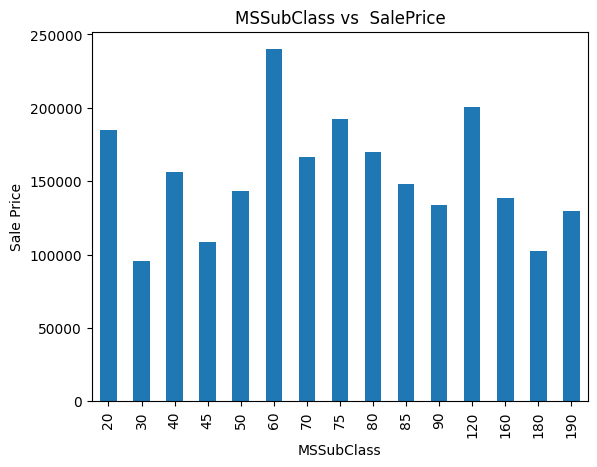

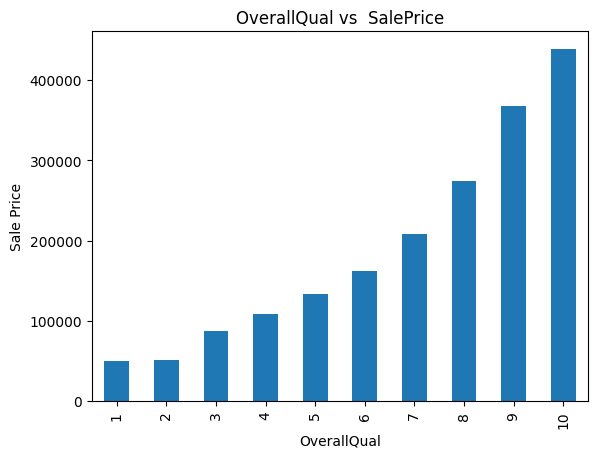

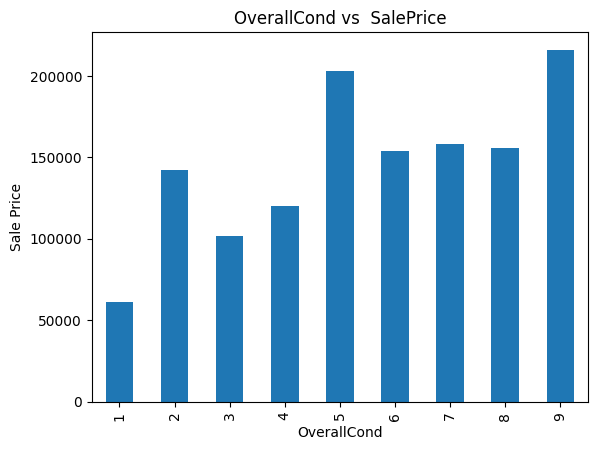

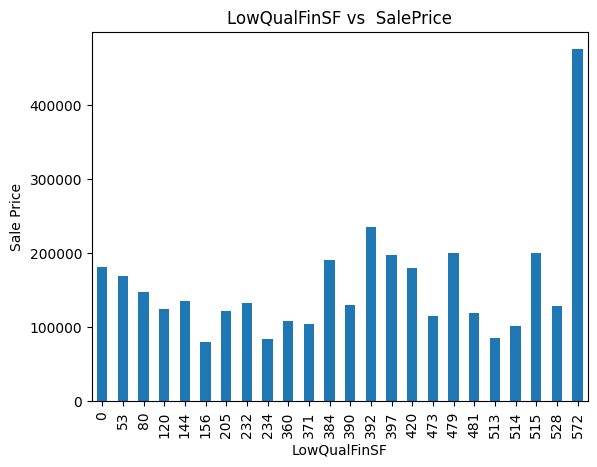

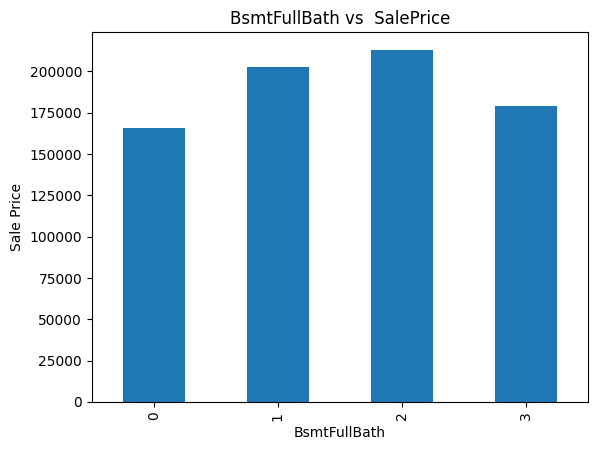

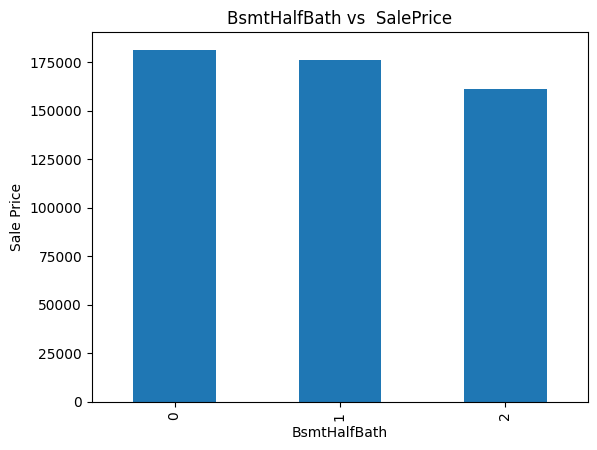

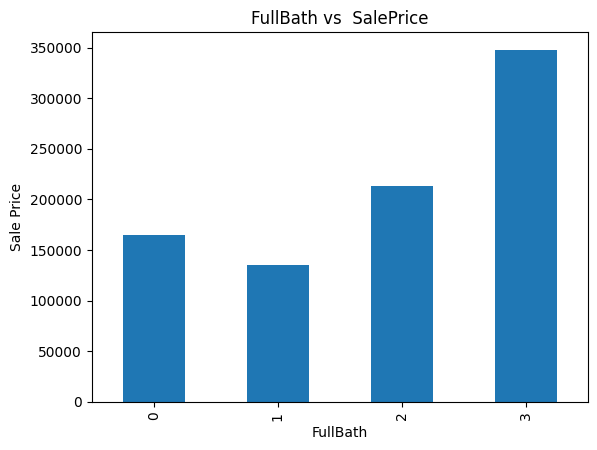

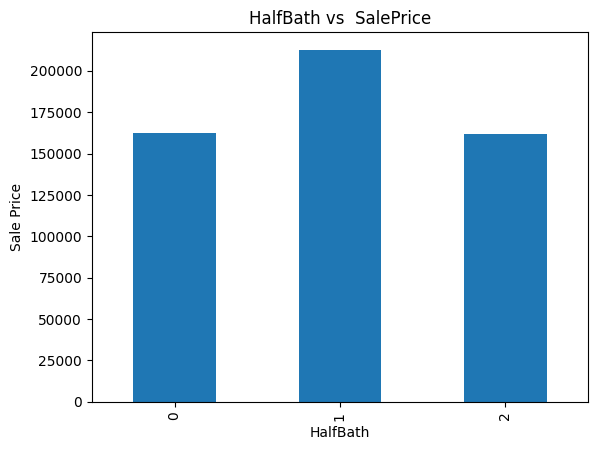

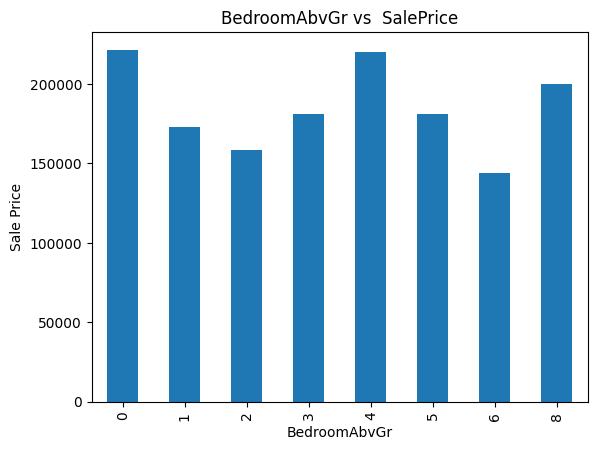

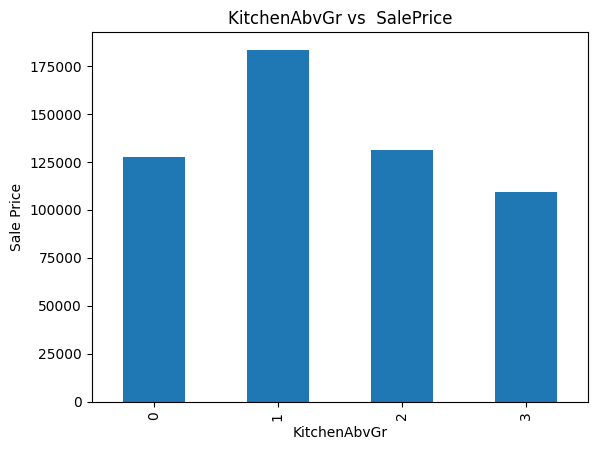

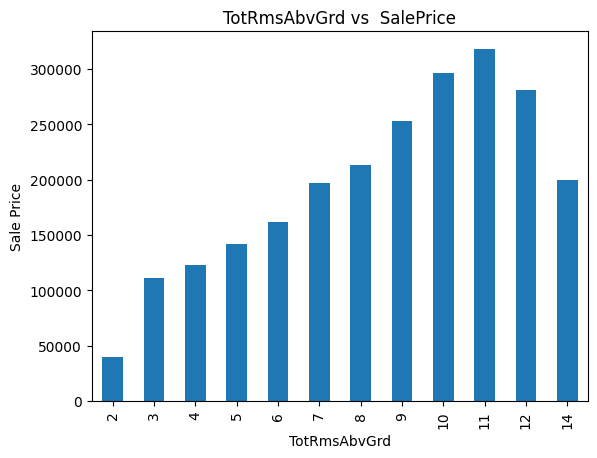

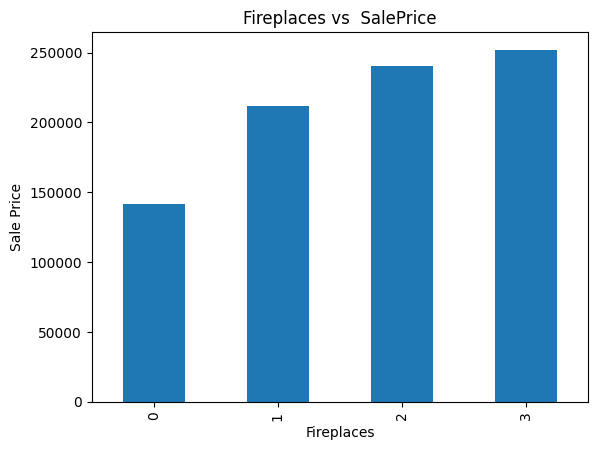

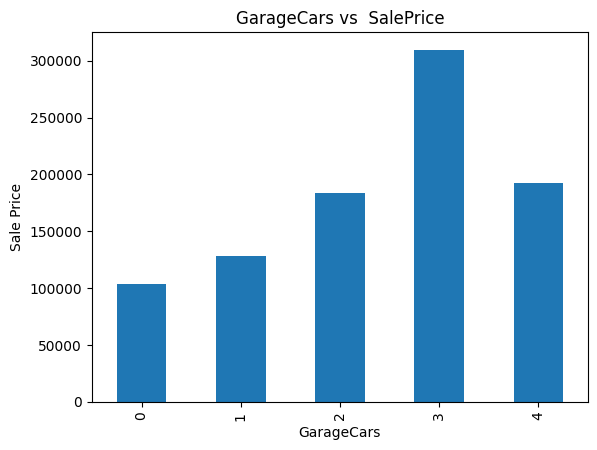

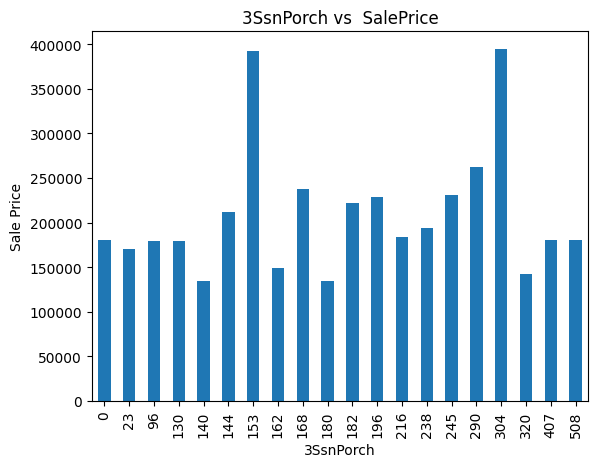

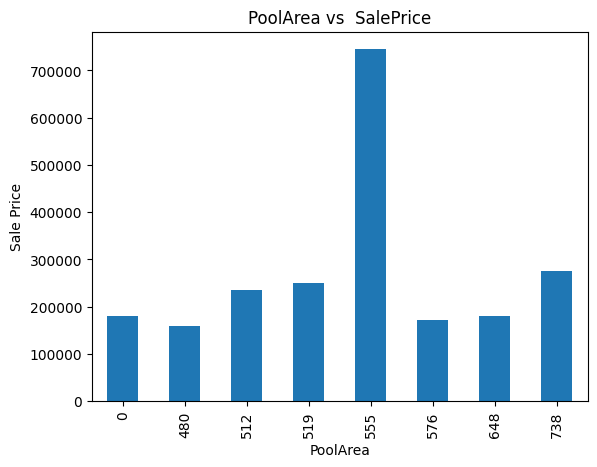

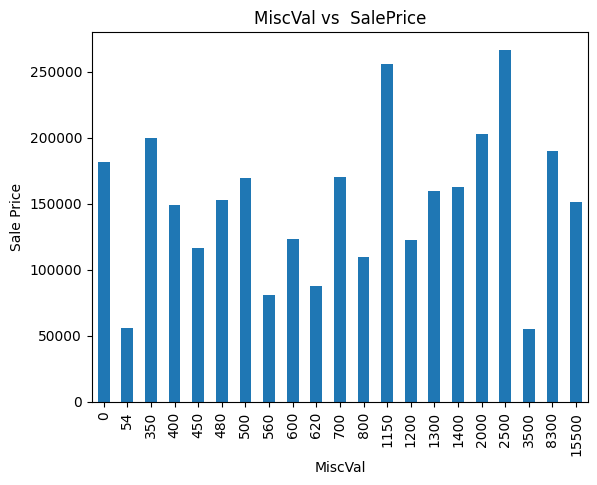

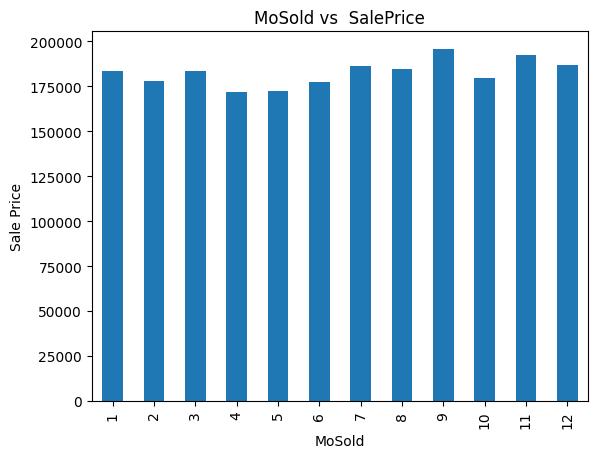

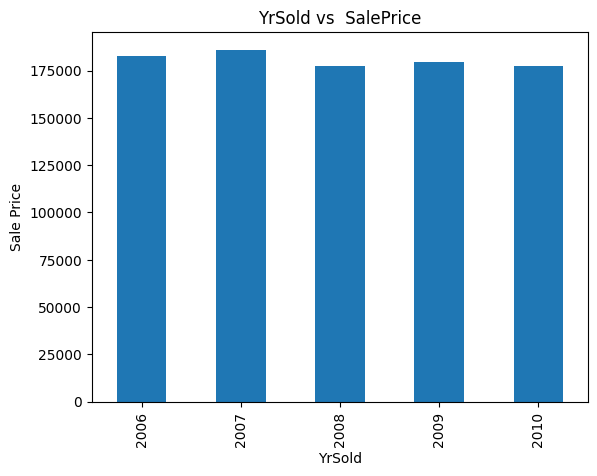

In [953]:
for num_col in num_columns:
  if len(data[num_col].unique())<=25 and num_col != 'SalePrice':
    data.groupby(num_col)['SalePrice'].mean().plot.bar()
    plt.xlabel(num_col)
    plt.ylabel('Sale Price')
    plt.title(num_col +' vs '+' SalePrice')
    plt.show()

In [929]:
# Se deben escalar los datos para usar con KNNImputer
data_scaled = data.copy()
scaler = MinMaxScaler()
data_scaled[na_num_cols] = scaler.fit_transform(data_scaled[na_num_cols])
data_scaled.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,0.150685,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,0.202055,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,0.160959,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,0.133562,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,0.215753,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [930]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", KNNImputer(n_neighbors=5), na_num_cols),
        ("cat", SimpleImputer(strategy="most_frequent"), na_cat_cols)
    ],
    remainder="passthrough",  # Mantiene las demás columnas sin cambios
    verbose_feature_names_out=False
).set_output(transform='pandas')

In [931]:
preprocessor.fit(data_scaled)
transformed_data = preprocessor.transform(data_scaled)
transformed_data = transformed_data[data.columns]
transformed_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,0.150685,8450,Pave,Grvl,Reg,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,2,2008,WD,Normal,208500
1,2,20,RL,0.202055,9600,Pave,Grvl,Reg,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,5,2007,WD,Normal,181500
2,3,60,RL,0.160959,11250,Pave,Grvl,IR1,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,9,2008,WD,Normal,223500
3,4,70,RL,0.133562,9550,Pave,Grvl,IR1,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,2,2006,WD,Abnorml,140000
4,5,60,RL,0.215753,14260,Pave,Grvl,IR1,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,12,2008,WD,Normal,250000


In [932]:
transformed_data.isna().sum().values

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [933]:
# Identificar las columnas categóricas
cat_cols = transformed_data.select_dtypes(include=['object']).columns

# Inicializar el OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)

# Aplicar OneHotEncoder solo a las columnas categóricas
encoder.fit(transformed_data[cat_cols])
encoded_cat_data = encoder.transform(transformed_data[cat_cols])

# Crear un DataFrame con los datos codificados
encoded_cat_df = pd.DataFrame(encoded_cat_data, columns=encoder.get_feature_names_out(cat_cols))

# Reemplazar las columnas categóricas originales con las codificadas
transformed_data = transformed_data.drop(columns=cat_cols)
transformed_data = pd.concat([transformed_data, encoded_cat_df], axis=1)

transformed_data

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,0.150685,8450,7,5,2003,2003,0.122500,706,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2,20,0.202055,9600,6,8,1976,1976,0.000000,978,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,3,60,0.160959,11250,7,5,2001,2002,0.101250,486,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,4,70,0.133562,9550,7,5,1915,1970,0.000000,216,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,5,60,0.215753,14260,8,5,2000,2000,0.218750,655,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,0.140411,7917,6,5,1999,2000,0.000000,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1456,1457,20,0.219178,13175,6,6,1978,1988,0.074375,790,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1457,1458,70,0.154110,9042,7,9,1941,2006,0.000000,275,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1458,1459,20,0.160959,9717,5,6,1950,1996,0.000000,49,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


<ipython-input-934-2240e1a6063e>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(transformed_data['SalePrice'])


<Axes: xlabel='SalePrice', ylabel='Density'>

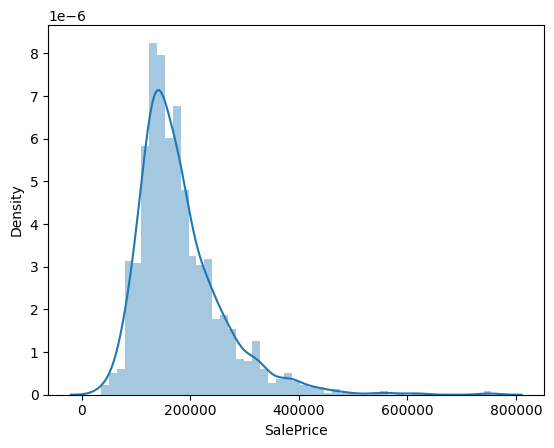

In [934]:
sns.distplot(transformed_data['SalePrice'])

## Entrenamiento del modelo

In [935]:
X = transformed_data.drop(columns=["SalePrice", "Id"], axis=1)
y = transformed_data["SalePrice"]

#Log Transform
y = np.log(y)

sc = StandardScaler()
X = sc.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X)

explained_variance = np.cumsum(pca.explained_variance_ratio_)

In [936]:
threshold = 0.95
optimal_components = np.argmax(explained_variance >= threshold) + 1
optimal_components

162

In [937]:
pca = PCA(n_components=optimal_components)
X = pca.fit_transform(X)

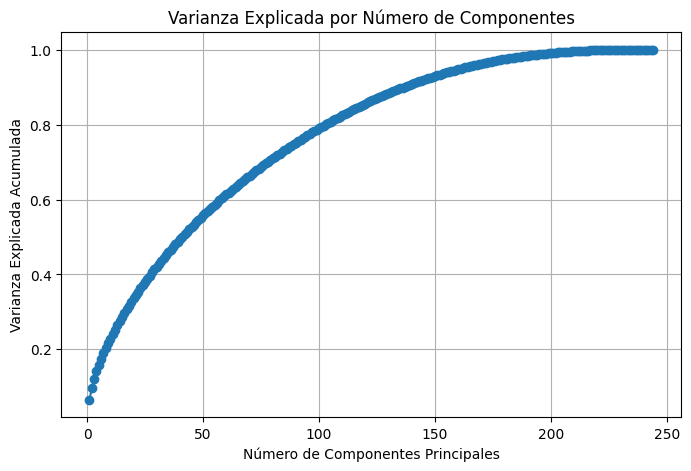

In [938]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Varianza Explicada por Número de Componentes')
plt.grid()
plt.show()

## Probando con distintos modelos con GridSearch

In [845]:
models = {

    "LinearRegression": {
        "model": LinearRegression(),
        "params": {}
    },

    "LightGBM": {
        "model": LGBMRegressor(random_state=42),
        "params": {
            "n_estimators": [10, 50],
            "max_depth": [3, 8],
            "learning_rate": [0.01, 0.1]
        }
    },

    "XGBoost": {
        "model": XGBRegressor(objective="reg:squarederror", random_state=42),
        "params": {
            "n_estimators": [10, 50],
            "max_depth": [3, 8],
            "learning_rate": [0.01, 0.1]
        }
    },

    "Lasso": {
        "model": Lasso(),
        "params": {
            "alpha": [0.1, 1.0, 10.0]
        }
    },

    "Ridge": {
        "model": Ridge(),
        "params": {
            "alpha": [0.1, 1.0, 10.0]
        }
    },

    "ElasticNet": {
        "model": ElasticNet(alpha=0.1, l1_ratio=0.5),
        "params": {
            "alpha": [0.1, 1.0],
            "l1_ratio": [0.1, 0.5]
        }
    }
}

# Diccionario para almacenar resultados
grid_results = {}

# Bucle sobre los modelos
for name, model_info in models.items():
    print(f"\nEntrenando modelo: {name}")

    grid_search = GridSearchCV(
        estimator=model_info["model"],
        param_grid=model_info["params"],
        scoring="neg_root_mean_squared_error",
        cv=5,
        n_jobs=-1
    )

    grid_search.fit(X, y)

    # Guardar resultados
    grid_results[name] = {
        "best_score": -grid_search.best_score_,  # Convertimos a positivo
        "best_params": grid_search.best_params_,
        "best_estimator": grid_search.best_estimator_
    }

    print(f"Mejor RMSE para {name}: {grid_results[name]['best_score']:.2f}")
    print(f"Mejores hiperparámetros: {grid_results[name]['best_params']}")

# Encontrar el mejor modelo
best_model = min(grid_results, key=lambda x: grid_results[x]["best_score"])
print(f"\nEl mejor modelo es: {best_model} con RMSE de {grid_results[best_model]['best_score']:.2f}")



Entrenando modelo: LinearRegression
Mejor RMSE para LinearRegression: 0.29
Mejores hiperparámetros: {}

Entrenando modelo: LightGBM


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006453 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 41310
[LightGBM] [Info] Number of data points in the train set: 1460, number of used features: 162
[LightGBM] [Info] Start training from score 12.024051
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

In [846]:
model = grid_results[best_model]["best_estimator"]
model

ElasticNet(alpha=0.1, l1_ratio=0.1)

### Confeccionando el Pipeline para generalización

En base a la investigación y pruebas previas, aquí se generará un Pipeline que realice el preprocesamiento y entrenamiento correspondiente, usando el modelo que GridSearch nos lanzó con mejores métricas.

Posteriormente, a modo de más pruebas, generaremos otros pipelines con otros modelos pero con parámetros por defecto de los mismos.

In [847]:
# Cargar los datos
data = pd.read_csv("./train.csv")

X = data.drop(columns=['SalePrice', 'Id'])
y = data['SalePrice']

# log transform
y = np.log(y)


In [848]:
models = {
    "XGBoost": XGBRegressor(objective="reg:squarederror", random_state=42, learning_rate=0.1, max_depth=3, n_estimators=50),
    "LinearRegression": LinearRegression(),
    "LightGBM": LGBMRegressor(n_estimators=50, learning_rate=0.1, max_depth=8, random_state=42),
    "Lasso": Lasso(alpha=0.1),
    "Ridge": Ridge(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5)
}

In [849]:
def create_models_pipelines_dict(models, X, y):

  # Identificar columnas numéricas y categóricas
  num_cols = X.select_dtypes(include=['int64', 'float64']).columns.to_list()
  cat_cols = X.select_dtypes(include=['object']).columns.to_list()

  # Identificar columnas con valores faltantes
  na_num_cols = X[num_cols].columns[X[num_cols].isnull().any()].tolist()
  na_cat_cols = X[cat_cols].columns[X[cat_cols].isnull().any()].tolist()

  # Pipeline de imputacion para datos numéricos
  num_pipeline = Pipeline([
      ('scaler_minmax', MinMaxScaler()),
      ('imputer', KNNImputer(n_neighbors=5))
  ])

  # Pipeline de imputacion para datos categóricos
  cat_pipeline = Pipeline([
      ('imputer', SimpleImputer(strategy='most_frequent')),
  ])

  # Combinamos las transformaciones
  preprocessor = ColumnTransformer([
      ('cat', cat_pipeline, na_cat_cols),
      ('num', num_pipeline, na_num_cols)
  ], remainder='passthrough', verbose_feature_names_out=False).set_output(transform='pandas')

  models_pipelines = {
      "name": [],
      "model": [],
      "RMSE": []
  }

  for name, model in models.items():

    models_pipelines["name"].append(name)

    # Pipeline general
    model_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('restore_columns', FunctionTransformer(lambda X: pd.DataFrame(X, columns=X.columns), validate=False)),
        ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)),
        ('scaler_standard', StandardScaler()),
        ('pca', PCA(n_components=optimal_components)),
        ('model', model)
    ])

    print(f"Entrenando modelo {name}...")

    model_pipeline.fit(X, y)

    rmse = np.sqrt(-cross_val_score(model_pipeline, X, y, scoring="neg_mean_squared_error", cv=5)).mean()

    print(f"Modelo {name} listo!")
    print("-"*30)

    models_pipelines["model"].append(model_pipeline)
    models_pipelines["RMSE"].append(rmse)

  return models_pipelines

In [850]:
models_pipelines = create_models_pipelines_dict(models, X, y)
results = pd.DataFrame(models_pipelines)
results

Entrenando modelo XGBoost...


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7, 16, 17, 18, 21, 38, 42, 44, 45, 46, 47, 51, 52, 53, 54, 66, 68, 69, 70, 71, 72, 73, 74] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3, 7, 16, 17, 18, 21, 30, 33, 34, 35, 44, 45, 46, 47, 49, 51, 52, 53, 54, 62, 66, 68, 69, 70, 72, 74] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [15, 16, 17, 18, 21, 35, 40, 44, 45, 46, 47, 51, 52, 53, 54, 55, 59, 62, 63, 66, 68, 69, 70, 71, 72, 73, 74] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sk

Modelo XGBoost listo!
------------------------------
Entrenando modelo LinearRegression...


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7, 16, 17, 18, 21, 38, 42, 44, 45, 46, 47, 51, 52, 53, 54, 66, 68, 69, 70, 71, 72, 73, 74] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3, 7, 16, 17, 18, 21, 30, 33, 34, 35, 44, 45, 46, 47, 49, 51, 52, 53, 54, 62, 66, 68, 69, 70, 72, 74] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [15, 16, 17, 18, 21, 35, 40, 44, 45, 46, 47, 51, 52, 53, 54, 55, 59, 62, 63, 66, 68, 69, 70, 71, 72, 73, 74] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sk

Modelo LinearRegression listo!
------------------------------
Entrenando modelo LightGBM...


...

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7, 16, 17, 18, 21, 38, 42, 44, 45, 46, 47, 51, 52, 53, 54, 66, 68, 69, 70, 71, 72, 73, 74] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3, 7, 16, 17, 18, 21, 30, 33, 34, 35, 44, 45, 46, 47, 49, 51, 52, 53, 54, 62, 66, 68, 69, 70, 72, 74] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [15, 16, 17, 18, 21, 35, 40, 44, 45, 46, 47, 51, 52, 53, 54, 55, 59, 62, 63, 66, 68, 69, 70, 71, 72, 73, 74] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sk

Modelo Ridge listo!
------------------------------
Entrenando modelo ElasticNet...


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7, 16, 17, 18, 21, 38, 42, 44, 45, 46, 47, 51, 52, 53, 54, 66, 68, 69, 70, 71, 72, 73, 74] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3, 7, 16, 17, 18, 21, 30, 33, 34, 35, 44, 45, 46, 47, 49, 51, 52, 53, 54, 62, 66, 68, 69, 70, 72, 74] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [15, 16, 17, 18, 21, 35, 40, 44, 45, 46, 47, 51, 52, 53, 54, 55, 59, 62, 63, 66, 68, 69, 70, 71, 72, 73, 74] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sk

Modelo ElasticNet listo!
------------------------------


,name,model,RMSE
0,XGBoost,"(ColumnTransformer(remainder='passthrough',\n ...",0.252880
1,LinearRegression,"(ColumnTransformer(remainder='passthrough',\n ...",0.223910
2,LightGBM,"(ColumnTransformer(remainder='passthrough',\n ...",0.243507
3,Lasso,"(ColumnTransformer(remainder='passthrough',\n ...",0.254207
4,Ridge,"(ColumnTransformer(remainder='passthrough',\n ...",0.224216
5,ElasticNet,"(ColumnTransformer(remainder='passthrough',\n ...",0.242831


<ipython-input-851-9a505ba2a222>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results["name"], y=results["RMSE"], palette=colors)


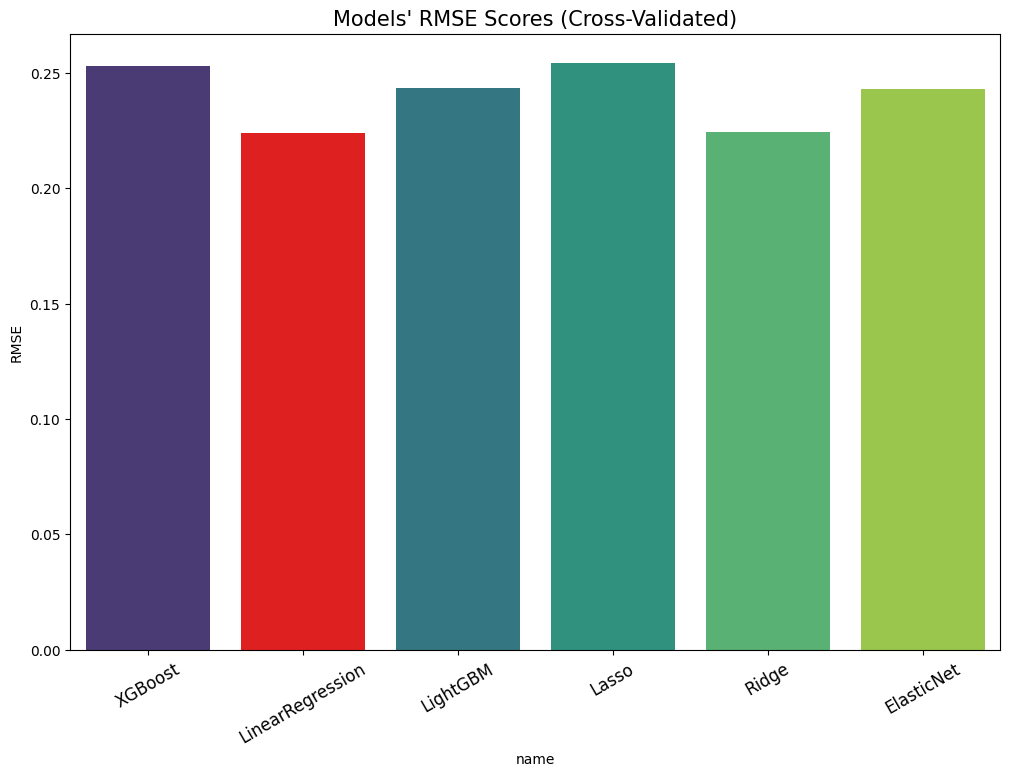

In [851]:
num_bars = len(results["name"])
colors = sns.color_palette("viridis", num_bars)

min_rmse_idx = np.argmin(results["RMSE"])

highlight_color = "red"
colors[min_rmse_idx] = highlight_color

plt.figure(figsize=(12, 8))
sns.barplot(x=results["name"], y=results["RMSE"], palette=colors)
plt.title("Models' RMSE Scores (Cross-Validated)", size=15)
plt.xticks(rotation=30, size=12)
plt.show()

In [852]:
# el modelo con menor error
model_pipeline = models_pipelines["model"][min_rmse_idx]

model_pipeline

/usr/local/lib/python3.11/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['Alley', 'MasVnrType',
                                                   'BsmtQual', 'BsmtCond',
                                                   'BsmtExposure',
                                                   'BsmtFinType1',
                                                   'BsmtFinType2', 'Electrical',
                                                   'FireplaceQu', 'GarageType',
                                                   'GarageFinish', 'GarageQual',
                                                   'GarageCond', 'PoolQC',
                                                   'Fence...
                                                   'GarageYrBlt'])],
                                   verbose_feature_names_out=False)),
                ('restore_columns',
                 FunctionTransformer(func=<function create_models_pipelines_dict.<locals>.<lambda> at 0x7d6b5cd2df80>)),
                ('encoder',
                 OneHotEncoder(drop='first', handle_unknown='ignore',
                               sparse_output=False)),
                ('scaler_standard', StandardScaler()),
                ('pca', PCA(n_components=162)), ('model', LinearRegression())])

In [853]:
y.mean()

12.024050901109383

## Generando predicciones de archivo de prueba

In [866]:
test = pd.read_csv("./test.csv")
test.shape

(1459, 80)

### Usando modelo, preprocesando a mano nuevamente

In [867]:
columns_with_na = test.columns[test.isnull().any()].tolist()
na_num_cols = test[columns_with_na].select_dtypes(include=['number', 'float64', 'int64']).columns.to_list()
na_cat_cols = test[columns_with_na].select_dtypes(include=['object']).columns.to_list()
cat_columns = test.select_dtypes(include=['object']).columns.to_list()

data_scaled = test.copy()
scaler = MinMaxScaler()
data_scaled[na_num_cols] = scaler.fit_transform(data_scaled[na_num_cols])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", KNNImputer(n_neighbors=5), na_num_cols),
        ("cat", SimpleImputer(strategy="most_frequent"), na_cat_cols)
    ],
    remainder="passthrough",  # Mantiene las demás columnas sin cambios
    verbose_feature_names_out=False
).set_output(transform='pandas')

transformed_data = preprocessor.fit_transform(data_scaled)
transformed_data = transformed_data[test.columns]

cat_cols = transformed_data.select_dtypes(include=['object']).columns

encoded_cat_data = encoder.transform(transformed_data[cat_cols])

# Crear un DataFrame con los datos codificados
encoded_cat_df = pd.DataFrame(encoded_cat_data, columns=encoder.get_feature_names_out(cat_cols))

# Reemplazar las columnas categóricas originales con las codificadas
transformed_data = transformed_data.drop(columns=cat_cols)
transformed_data = pd.concat([transformed_data, encoded_cat_df], axis=1)

X = transformed_data.drop(columns=["Id"], axis=1)
X.isna().sum().values

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

In [868]:
X = sc.transform(X)
X = pca.transform(X)

In [875]:
y_pred = np.exp(model.predict(X))
y_pred

array([104061.88087437, 146193.37950871, 166013.43394596, ...,
       147610.31842361, 120334.96213502, 184187.64145477])

### Usando modelo de Pipeline

In [876]:
y_pred_pipeline = np.exp(model_pipeline.predict(test.drop(["Id"], axis=1)))
y_pred_pipeline

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [16, 17, 18, 19, 20, 21, 25, 35, 39, 40, 44, 45, 46, 47, 51, 52, 53, 54, 55, 56, 57, 61, 62, 63, 64, 65, 66, 68, 69, 70, 71, 72, 73, 74, 77] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


array([112440.55165591, 148892.79315726, 200278.78491783, ...,
       165013.79287054, 146351.62554974, 213179.67162828])

### Exportamos resultados

In [877]:
result_y_pred = pd.concat([test["Id"], pd.Series(y_pred)], axis=1)
result_y_pred.columns = ['Id', 'SalePrice']
result_y_pred.to_csv('test1.csv', index=False)

In [878]:
result_y_pred_pipeline = pd.concat([test["Id"], pd.Series(y_pred_pipeline)], axis=1)
result_y_pred_pipeline.columns = ['Id', 'SalePrice']
result_y_pred_pipeline.to_csv('test2.csv', index=False)